In [31]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

In [3]:
train_images = train_images.reshape((60000,28,28,1))
test_images = test_images.reshape((10000,28,28,1))

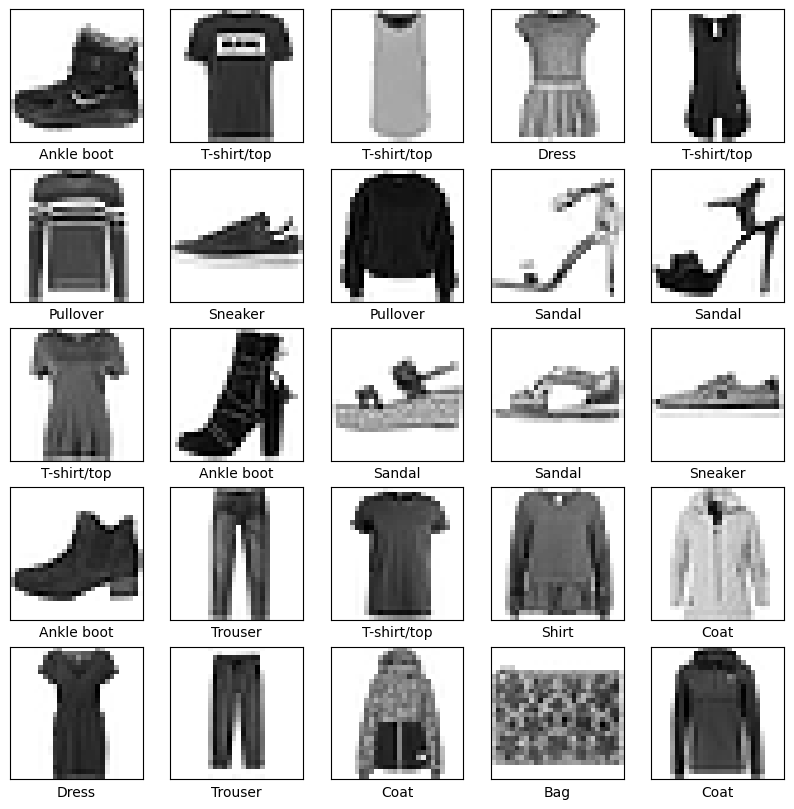

In [4]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])

plt.show()

In [5]:
model = keras.Sequential([

    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),

    keras.layers.Flatten(),

    keras.layers.Dense(128,activation='relu'),

    keras.layers.Dense(10,activation='softmax')

])

c:\Users\DHEERAJ\ai_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [8]:
history = model.fit(
train_images,
train_labels,
epochs=10,
validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8119 - loss: 0.5584 - val_accuracy: 0.8560 - val_loss: 0.3884
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8704 - loss: 0.3543 - val_accuracy: 0.8547 - val_loss: 0.3766
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8856 - loss: 0.3120 - val_accuracy: 0.8743 - val_loss: 0.3382
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8934 - loss: 0.2872 - val_accuracy: 0.8813 - val_loss: 0.3234
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9008 - loss: 0.2655 - val_accuracy: 0.8853 - val_loss: 0.3200
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9083 - loss: 0.2482 - val_accuracy: 0.8920 - val_loss: 0.3127
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9122 - loss: 0.2364 - val_accuracy: 0.8856 - val_loss: 0.3219
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9144 - loss: 0.2264

In [9]:
test_loss, test_acc = model.evaluate(test_images,test_labels)

print("Test Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8843 - loss: 0.3665
Test Accuracy: 0.8842999935150146


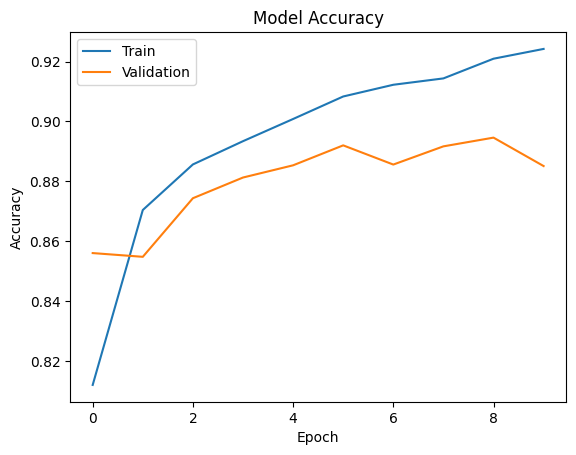

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


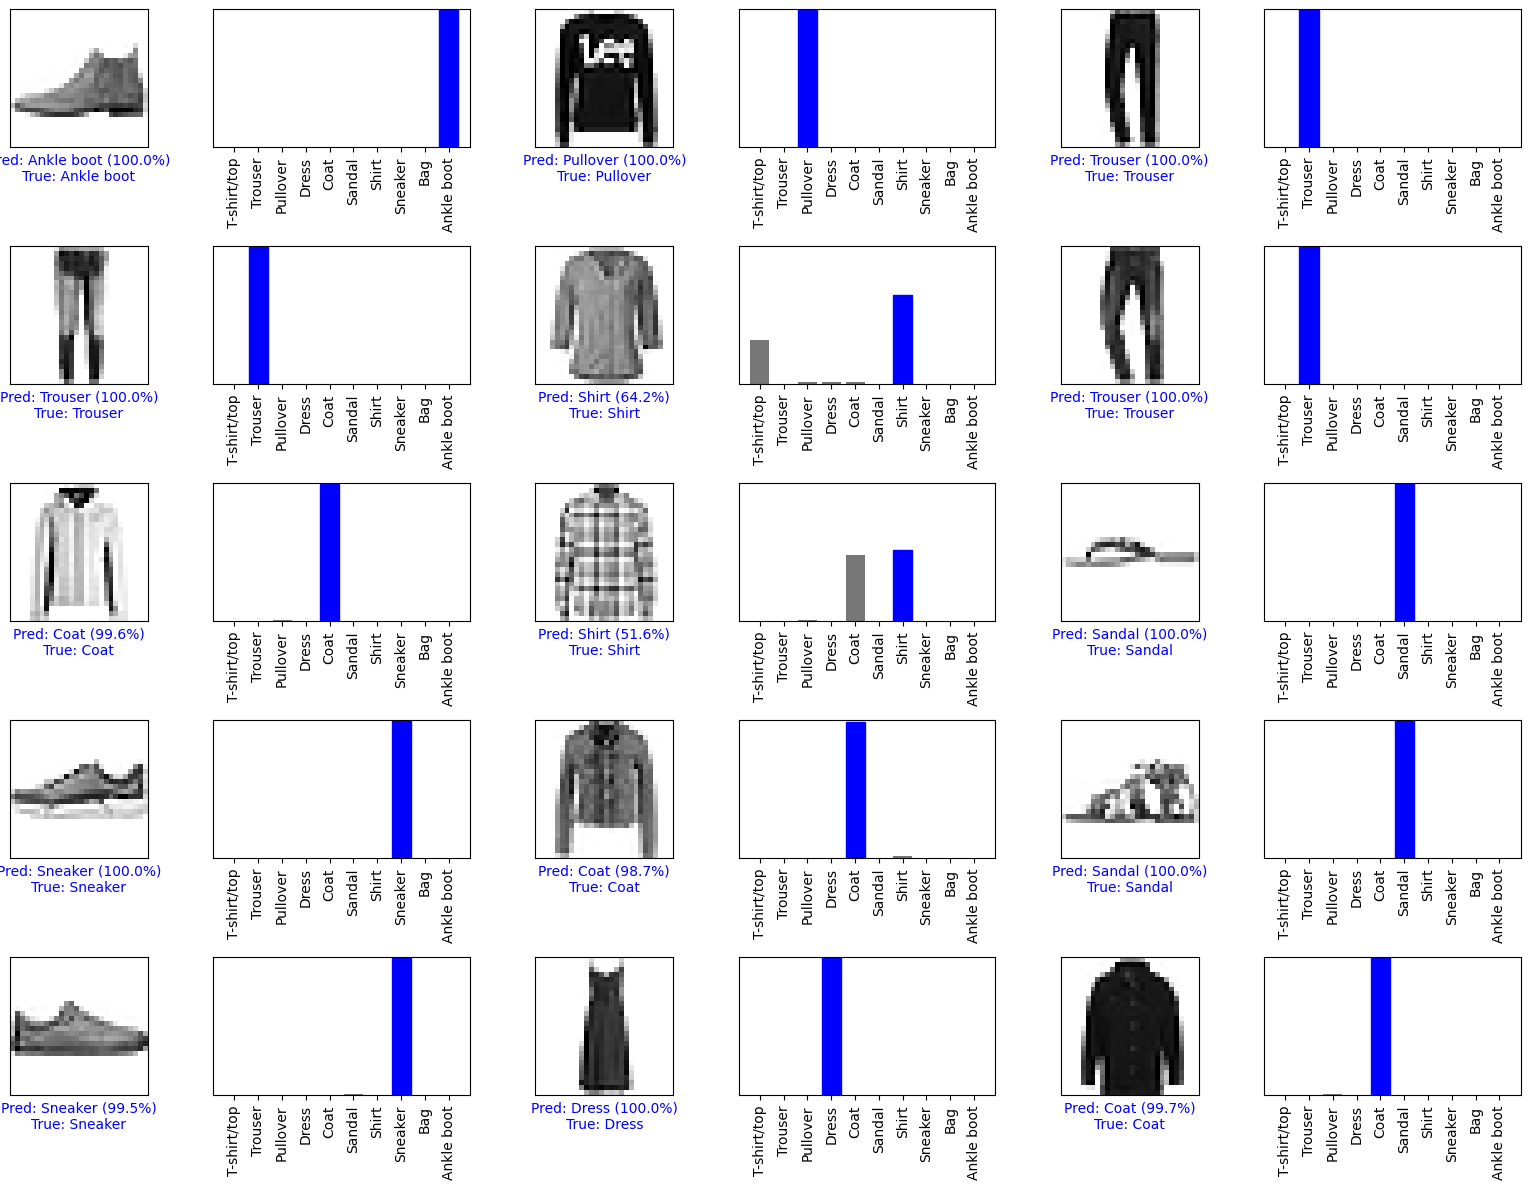

In [28]:
# Generate predictions
predictions = model.predict(test_images)


# Function to plot image with prediction
def plot_image(i, predictions_array, true_label, img):

    true_label, img = true_label[i], img[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img.reshape(28,28), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    confidence = 100 * np.max(predictions_array)

    if predicted_label == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel(
        f"Pred: {class_names[predicted_label]} ({confidence:.1f}%)\nTrue: {class_names[true_label]}",
        color=color
    )


# Function to plot probability distribution
def plot_value_array(i, predictions_array, true_label):

    true_label = true_label[i]

    plt.grid(False)
    plt.yticks([])

    # Show class names instead of numbers
    plt.xticks(range(10), class_names, rotation=90)

    thisplot = plt.bar(range(10), predictions_array, color="#777777")

    plt.ylim([0,1])

    predicted_label = np.argmax(predictions_array)

    # Predicted class = red
    thisplot[predicted_label].set_color("red")

    # True class = blue
    thisplot[true_label].set_color("blue")


# Display predictions in grid
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(16,12))

for i in range(num_images):

    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)

    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)

plt.tight_layout()

# Save image for GitHub README
plt.savefig("cnn_predictions.png", dpi=300)

plt.show()

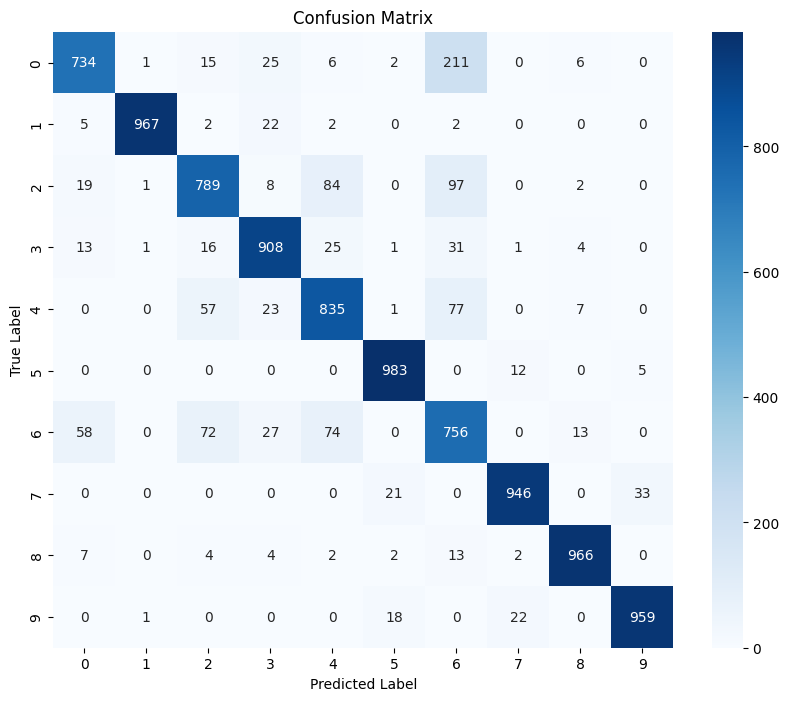

In [32]:
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")
plt.show()